# Hailmary cluster artifact audit

This notebook builds and audits the six-cluster KDFW/RW18R cluster-library artifact. Set `HAILMARY_CLUSTER_ARTIFACT` to inspect a different artifact; the audit refuses to display a result other than six clusters.

In order for this notebook to work, we ought to run the following scripts:

In [1]:
from pathlib import Path
import subprocess
import sys

project_root = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (parent / "pyproject.toml").is_file())
subprocess.run([sys.executable, str(project_root / "scripts/build_hailmary_clusters.py")], check=True)

{'artifact': '/Volumes/CrucialX/project-rustlingtree/artifacts/hailmary/clusters.json', 'content_hash': '45776f6242ab2683018a9325b90fa571552d1af2dd74334d9d61d657ce3db50c', 'cluster_count': 6, 'selected_parameters': {'cluster_selection_method': 'eom', 'min_cluster_size': 8, 'min_samples': 3}, 'accepted_tracks': 243, 'rejection_counts': {'endpoint_outside_capture_radius': 174, 'missing_raw_track': 9, 'no_inbound_crossing': 3}}


CompletedProcess(args=['/opt/homebrew/Caskroom/miniforge/base/envs/rustlingtree/bin/python3.14', '/Volumes/CrucialX/project-rustlingtree/scripts/build_hailmary_clusters.py'], returncode=0)

In [2]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np

from hailmary.clustering import ClusterLibrary

project_root = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (parent / "pyproject.toml").is_file())
default_artifact_path = project_root / "artifacts/hailmary/clusters.json"
artifact_path = Path(os.environ.get("HAILMARY_CLUSTER_ARTIFACT", default_artifact_path)).expanduser().resolve()
artifact_path

PosixPath('/Volumes/CrucialX/project-rustlingtree/artifacts/hailmary/clusters.json')

## 1. Load and verify the content-addressed artifact

`ClusterLibrary.read` recomputes and verifies the canonical content hash.

In [3]:
library = ClusterLibrary.read(artifact_path)
if len(library.medoids) != 6:
    raise RuntimeError(f"Expected six clusters at {artifact_path}, found {len(library.medoids)}. Restart the kernel and rerun the build cell.")

{
    "dataset_id": library.dataset_id,
    "partition": f"{library.airport}/{library.runway}",
    "station_count": library.resample_station_count,
    "cluster_count": len(library.medoids),
    "assignment_count": len(library.assignments),
    "algorithm": library.clustering.algorithm,
    "used_fallback": library.clustering.used_fallback,
    "content_hash": library.artifact_content_hash,
}

{'dataset_id': 'kdfw-2026-04-01',
 'partition': 'KDFW/RW18R',
 'station_count': 128,
 'cluster_count': 6,
 'assignment_count': 243,
 'algorithm': 'hdbscan',
 'used_fallback': False,
 'content_hash': '45776f6242ab2683018a9325b90fa571552d1af2dd74334d9d61d657ce3db50c'}

## 2. Inspect the observed medoid geometries

Coordinates are runway-local metres and tracks run from terminal entry toward the threshold.

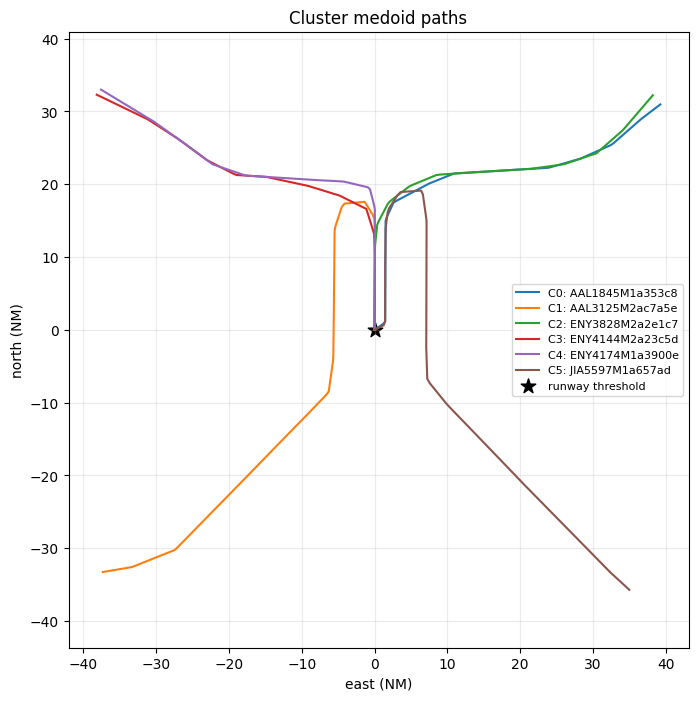

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
for medoid in library.medoids:
    points = medoid.points_m
    ax.plot(points[:, 0] / 1852.0, points[:, 1] / 1852.0, label=f"C{medoid.cluster_id}: {medoid.medoid_flight_id}")
ax.scatter([0.0], [0.0], marker="*", s=120, color="black", label="runway threshold")
ax.set(xlabel="east (NM)", ylabel="north (NM)", title="Cluster medoid paths")
ax.axis("equal")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
plt.show()

## 3. Audit noise reassignment and OOD provenance

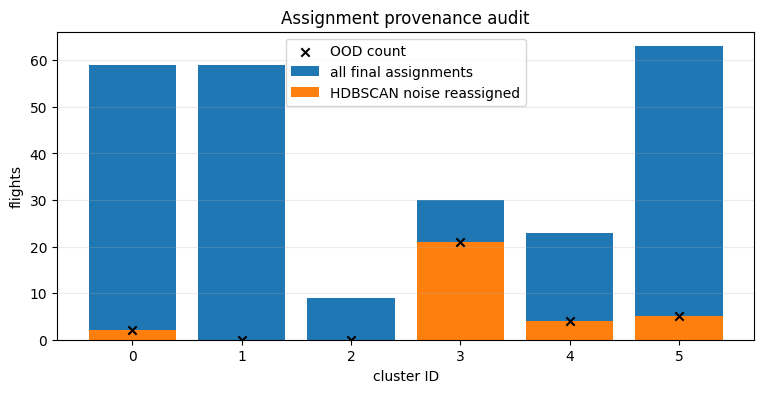

In [5]:
cluster_ids = sorted({item.cluster_id for item in library.assignments})
counts = [sum(item.cluster_id == cluster_id for item in library.assignments) for cluster_id in cluster_ids]
noise_counts = [sum(item.cluster_id == cluster_id and item.was_hdbscan_noise for item in library.assignments) for cluster_id in cluster_ids]
ood_counts = [sum(item.cluster_id == cluster_id and item.out_of_distribution for item in library.assignments) for cluster_id in cluster_ids]

x = np.arange(len(cluster_ids))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, counts, label="all final assignments")
ax.bar(x, noise_counts, label="HDBSCAN noise reassigned")
ax.scatter(x, ood_counts, marker="x", color="black", label="OOD count")
ax.set(xticks=x, xticklabels=cluster_ids, xlabel="cluster ID", ylabel="flights", title="Assignment provenance audit")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()